In [188]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [189]:
df = pd.read_csv("/content/heart.csv")

In [190]:
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


In [191]:
df.shape

(1025, 14)

In [192]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [193]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [194]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [195]:
df.duplicated().sum()

np.int64(723)

In [196]:
a = df.columns
a

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

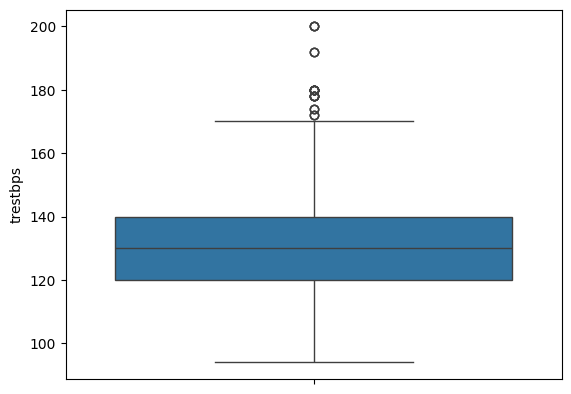

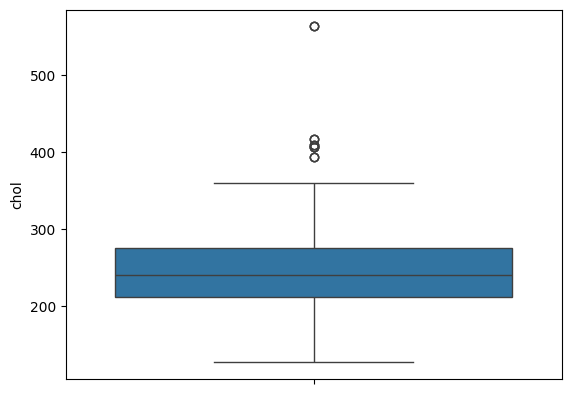

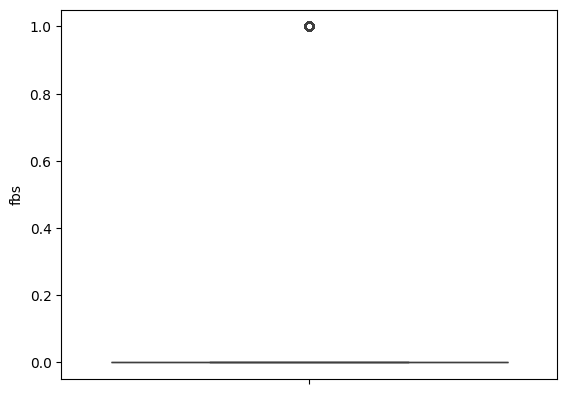

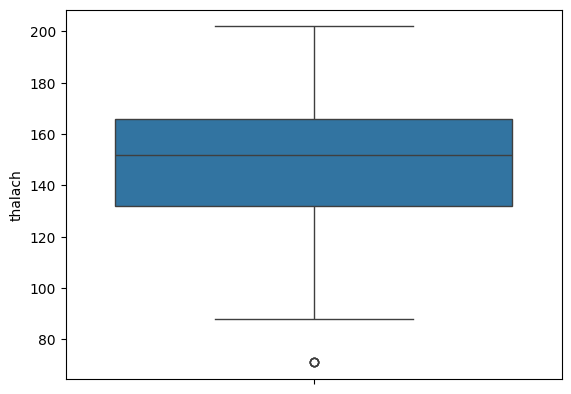

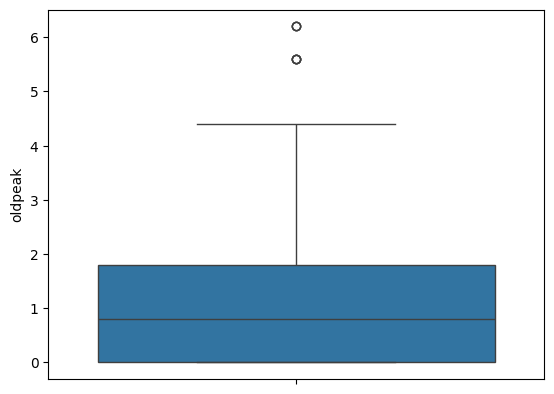

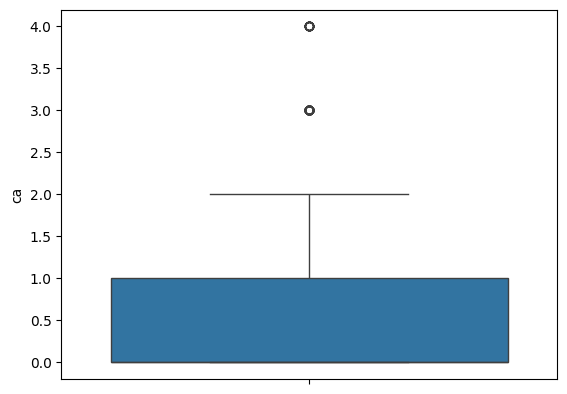

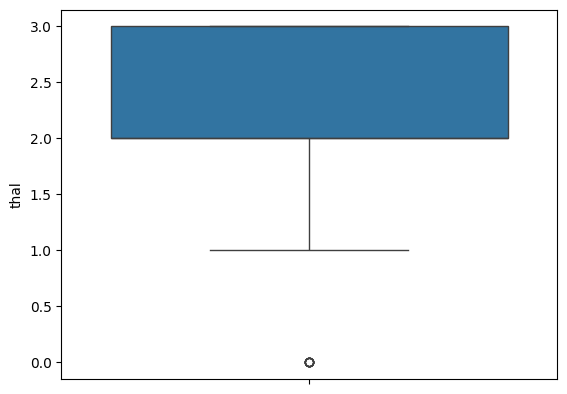

In [197]:
l = ['trestbps', 'chol', 'fbs','thalach','oldpeak','ca', 'thal']
for i in l:
  sns.boxplot(df[i])
  plt.show()

In [198]:
for i in l:
  q1 = df[i].quantile(0.25)
  q3 = df[i].quantile(0.75)
  iqr = q3-q1
  upper = q3+1.5*iqr
  lower = q1-1.5*iqr
  df[i] = df[i].clip(lower,upper)

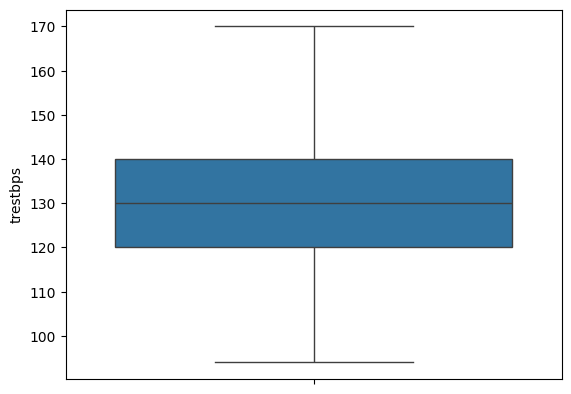

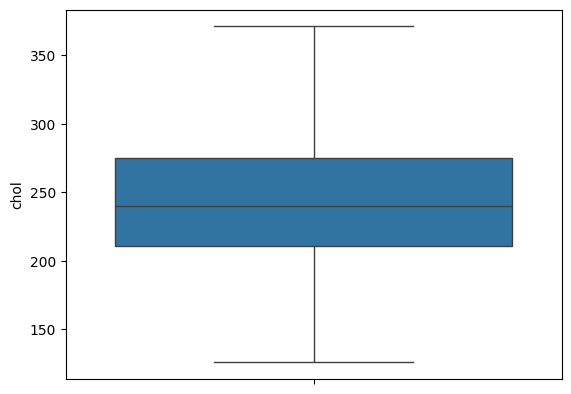

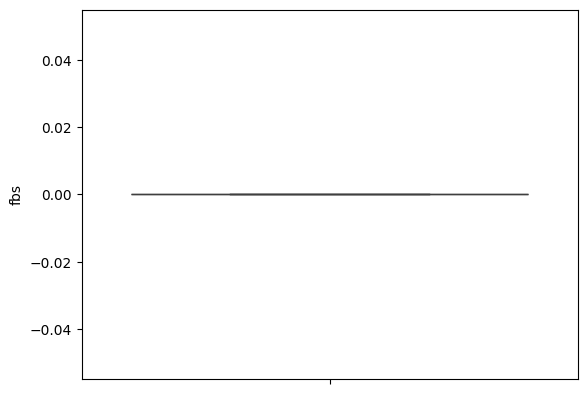

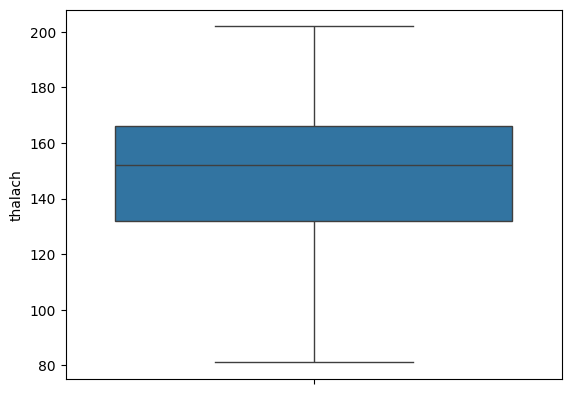

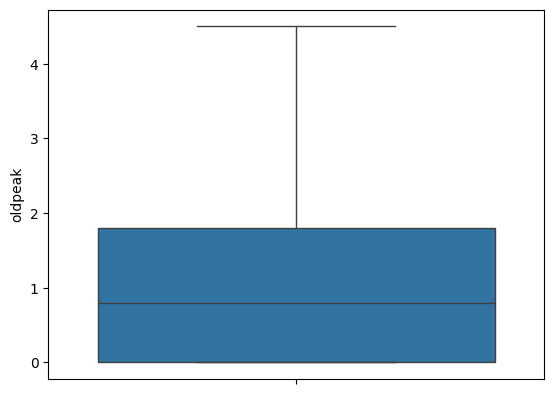

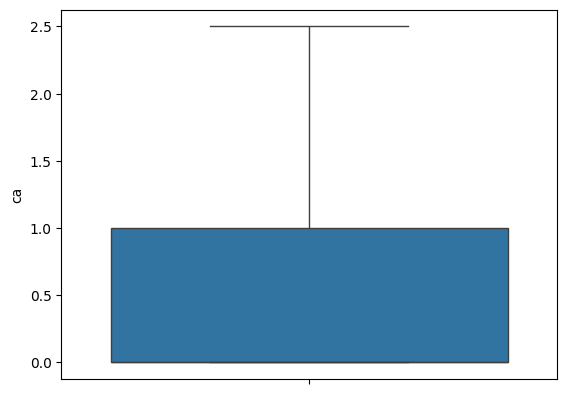

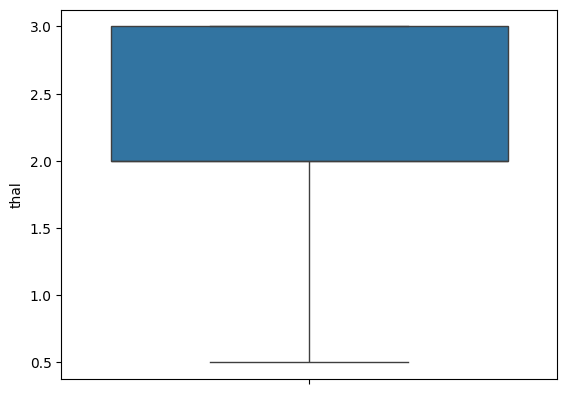

In [199]:
for i in l:
  sns.boxplot(df[i])
  plt.show()

In [200]:
x= df.drop('target',axis=1)
y= df['target']

LOGISTIC REGRESSION

In [201]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,precision_score,recall_score,f1_score

In [202]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [203]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.fit_transform(x_test)

In [204]:
lg = LogisticRegression()
lg.fit(x_train,y_train)

LogisticRegression()

In [205]:
y_predict = lg.predict(x_test)

In [206]:
print(classification_report(y_predict,y_test))

              precision    recall  f1-score   support

           0       0.70      0.90      0.78        79
           1       0.92      0.75      0.83       126

    accuracy                           0.81       205
   macro avg       0.81      0.83      0.81       205
weighted avg       0.84      0.81      0.81       205



In [207]:
lg_pre = precision_score(y_predict,y_test)
lf_re = recall_score(y_predict,y_test)
lg_f1 = f1_score(y_predict,y_test)
lg_report = classification_report(y_predict,y_test)

In [208]:
lg_acc = accuracy_score(y_test,y_predict)
lg_acc

0.8097560975609757

In [209]:
cn_matrix = confusion_matrix(y_test,y_predict)
print(cn_matrix)

[[71 31]
 [ 8 95]]


KNN CLASSIFIER

In [210]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [211]:
kn_predict = knn.predict(x_test)

In [212]:
print(classification_report(kn_predict,y_test))

              precision    recall  f1-score   support

           0       0.76      0.87      0.81        90
           1       0.88      0.79      0.83       115

    accuracy                           0.82       205
   macro avg       0.82      0.83      0.82       205
weighted avg       0.83      0.82      0.83       205



In [213]:
kn_pre= precision_score(kn_predict,y_test)
kn_re = recall_score(kn_predict,y_test)
kn_f1 = f1_score(kn_predict,y_test)

In [214]:
knn_acc = accuracy_score(kn_predict,y_test)
knn_acc

0.824390243902439

In [215]:
cn_matrix = confusion_matrix(y_test,kn_predict)
print(cn_matrix)

[[78 24]
 [12 91]]


RANDOM FOREST

In [216]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(x_train,y_train)

RandomForestClassifier()

In [217]:
rf_predict = rf.predict(x_test)

In [218]:
print(classification_report(rf_predict,y_test))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99       105
           1       0.97      1.00      0.99       100

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



In [219]:
rf_pre= precision_score(rf_predict,y_test)
rf_re = recall_score(rf_predict,y_test)
rf_f1 = f1_score(rf_predict,y_test)

In [220]:
rf_acc = accuracy_score(rf_predict,y_test)
rf_acc

0.9853658536585366

In [221]:
cn_matrix = confusion_matrix(y_test,rf_predict)
print(cn_matrix)

[[102   0]
 [  3 100]]


evaluation of model after droping duplicates

In [222]:
dup =df

In [223]:
cc = dup.drop_duplicates()

In [224]:
cc

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2.0,3.0,0
1,53,1,0,140,203,0,0,155,1,3.1,0,0.0,3.0,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0.0,3.0,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1.0,3.0,0
4,62,0,0,138,294,0,1,106,0,1.9,1,2.5,2.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,68,0,2,120,211,0,0,115,0,1.5,1,0.0,2.0,1
733,44,0,2,108,141,0,1,175,0,0.6,1,0.0,2.0,1
739,52,1,0,128,255,0,1,161,1,0.0,2,1.0,3.0,0
843,59,1,3,160,273,0,0,125,0,0.0,2,0.0,2.0,0


In [225]:
cc.shape

(302, 14)

In [226]:
cc.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [227]:
cc_x = cc.drop('target',axis=1)
cc_y = cc['target']

In [228]:
cc_x_train,cc_x_test,cc_y_train,cc_y_test = train_test_split(cc_x,cc_y,test_size=0.2,random_state=42)

In [229]:
sc = StandardScaler()
cc_x_train = sc.fit_transform(cc_x_train)
cc_x_test = sc.fit_transform(cc_x_test)

In [230]:
lg = LogisticRegression()
lg.fit(cc_x_train,cc_y_train)

LogisticRegression()

In [231]:
cc_y_predict = lg.predict(cc_x_test)

In [232]:
print(classification_report(cc_y_predict,cc_y_test))

              precision    recall  f1-score   support

           0       0.62      0.91      0.74        22
           1       0.93      0.69      0.79        39

    accuracy                           0.77        61
   macro avg       0.78      0.80      0.77        61
weighted avg       0.82      0.77      0.77        61



In [233]:
lg_af_pre= precision_score(cc_y_predict,cc_y_test)
lg_af_re = recall_score(cc_y_predict,cc_y_test)
lg_af_f1 = f1_score(cc_y_predict,cc_y_test)

In [234]:
lg_af_acc = accuracy_score(cc_y_predict,cc_y_test)
lg_af_acc


0.7704918032786885

In [235]:
cn_matrix = confusion_matrix(cc_y_test,cc_y_predict)
print(cn_matrix)

[[20 12]
 [ 2 27]]


KNN NEIGHBOUR

In [236]:
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(cc_x_train,cc_y_train)


KNeighborsClassifier()

In [237]:
knn_CC_predict = knn.predict(cc_x_test)

In [238]:
print(classification_report(knn_CC_predict,cc_y_test))

              precision    recall  f1-score   support

           0       0.66      0.88      0.75        24
           1       0.90      0.70      0.79        37

    accuracy                           0.77        61
   macro avg       0.78      0.79      0.77        61
weighted avg       0.80      0.77      0.77        61



In [239]:
knn_af_pre = precision_score(knn_CC_predict,cc_y_test)
knn_af_re = recall_score(knn_CC_predict,cc_y_test)
knn_af_f1 = f1_score(knn_CC_predict,cc_y_test)

In [240]:
knn_af_acc = accuracy_score(knn_CC_predict,cc_y_test)
knn_af_acc

0.7704918032786885

In [241]:
cn_matrix = confusion_matrix(cc_y_test,knn_CC_predict)
print(cn_matrix)

[[21 11]
 [ 3 26]]


RANDOM FOREST

In [242]:
rf= RandomForestClassifier()
rf.fit(cc_x_train,cc_y_train)

RandomForestClassifier()

In [243]:
rf_cc_predict = rf.predict(cc_x_test)

In [244]:
print(classification_report(rf_cc_predict,cc_y_test))


              precision    recall  f1-score   support

           0       0.78      0.89      0.83        28
           1       0.90      0.79      0.84        33

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



In [245]:
rf_af_pre = precision_score(rf_cc_predict,cc_y_test)
rf_af_re = recall_score(rf_cc_predict,cc_y_test)
rf_af_f1 = f1_score(rf_cc_predict,cc_y_test)

In [246]:
rf_af_acc = accuracy_score(rf_cc_predict,cc_y_test)
rf_af_acc

0.8360655737704918

In [247]:
cn_matrix = confusion_matrix(cc_y_test,rf_cc_predict)
print(cn_matrix)

[[25  7]
 [ 3 26]]


comparasion of accuraccy:

In [248]:
l_model = ['logistic regression','knn','random forest']
l_acc = [lg_acc,knn_acc,rf_acc]
l_pre = [lg_pre,kn_pre,rf_pre]
l_re = [lf_re,kn_re,rf_re]
l_f1 = [lg_f1,kn_f1,rf_f1]
acc = pd.DataFrame({'model':l_model,'accuracy':l_acc,'precision':l_pre,'recall':l_re,'f1_score':l_f1})
acc



,model,accuracy,precision,recall,f1_score
0,logistic regression,0.809756,0.922330,0.753968,0.829694
1,knn,0.824390,0.883495,0.791304,0.834862
2,random forest,0.985366,0.970874,1.000000,0.985222


Best-Performing Model: Random Forest
Based on all four evaluation metrics, Random Forest is clearly the best-performing model.
Justification
- Accuracy = 98.54% → Random Forest correctly classifies almost all observations and is significantly better than Logistic Regression and KNN.
- Precision = 97.09% → When Random Forest predicts the positive class, it is correct about 97% of the time, meaning very few false positives.
- Recall = 100% → It identifies all actual positive cases, with no false negatives in this test set.
- F1-score = 98.52% → This combines precision and recall, and the very high value shows that Random Forest provides an excellent balance between the two.
Final conclusion
Random Forest should be selected as the best model because it has the highest Accuracy, Precision, Recall, and F1-score among all three models. Its 100% recall and 98.52% F1-score make it particularly strong for this classification problem

comparasion of accuraccy after dropping duplicates

In [249]:
af_acc_mo = ['logistic regression','knn','random forest']
af_acc = [lg_af_acc,knn_af_acc,rf_af_acc]
af_pre = [lg_af_pre,knn_af_pre,rf_af_pre]
af_re = [lg_af_re,knn_af_re,rf_af_re]
af_f1 = [lg_af_f1,knn_af_f1,rf_af_f1]
acc_af = pd.DataFrame({'model':af_acc_mo,'accuracy':af_acc,'precision':af_pre,'recall':af_re,'f1_score':af_f1})
acc_af

,model,accuracy,precision,recall,f1_score
0,logistic regression,0.770492,0.931034,0.692308,0.794118
1,knn,0.770492,0.896552,0.702703,0.787879
2,random forest,0.836066,0.896552,0.787879,0.838710


Best Model: Random Forest
Random Forest is still the best-performing model after removing duplicates.
- Accuracy: 85.25% — highest overall correct prediction rate.
- Precision: 93.10% — tied with Logistic Regression and indicates very few false positives.
- Recall: 79.41% — highest recall, meaning it identifies more actual positive cases.
- F1-score: 85.71% — highest balance between precision and recall.
Important Observation
Previously, Random Forest achieved 98.54% accuracy and 100% recall. After removing the 725 duplicate records, its performance decreased to 85.25% accuracy and 79.41% recall.
This suggests that the duplicate records were likely making the original model evaluation overly optimistic. Removing duplicates gives a more realistic estimate of model performance and reduces the possibility that repeated observations influenced the results.